# Real Validation Matrices: FP32 vs FP64 Comparison
This notebook compares the performance of FP32 versus FP64 precision specifically on the real validation matrices dataset.

**Target Systems & Formats:**
- NVIDIA-H100: `CUSPARSE_CSR` (`cu-CSR`)
- NVIDIA-RTX3060: `CUSPARSE_CSR` (`cu-CSR`)
- ARM-GRACE-72: `ARMPL` (`ARM-lib`)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")

# Define plotting parameters
systems = ['NVIDIA-H100', 'ARM-GRACE-72', 'NVIDIA-RTX3060', ]
colors = {'NVIDIA-H100': '#1f77b4', 'ARM-GRACE-72': '#2ca02c', 'NVIDIA-RTX3060': '#ff7f0e'}

ROOT_DIR = './Plots/validation/fp32_vs_fp64/'
os.makedirs(ROOT_DIR, exist_ok=True)

In [2]:
# Load the datasets (Make sure these were successfully generated!)
df_fp64 = pd.read_csv('validation_real_benchmarks_all-devices_all.csv')
df_fp32 = pd.read_csv('validation_real_benchmarks_all-devices_all_fp32.csv')

def filter_data(df):
    # Keep only the target systems and formats
    cond_h100 = (df['System'] == 'NVIDIA-H100') & (df['format_name'] == 'CUSPARSE_CSR')
    cond_arm = (df['System'] == 'ARM-GRACE-72') & (df['format_name'] == 'ARMPL')
    cond_rtx = (df['System'] == 'NVIDIA-RTX3060') & (df['format_name'] == 'CUSPARSE_CSR')
    return df[cond_h100 | cond_arm | cond_rtx]

df_fp64_f = filter_data(df_fp64)
df_fp32_f = filter_data(df_fp32)

print(f"FP64 records: {len(df_fp64_f)}")
print(f"FP32 records: {len(df_fp32_f)}")

FP64 records: 156
FP32 records: 156


In [3]:
merge_cols = ['matrix_name', 'System', 'format_name']

# Keep structural columns from fp64
structural_cols = ['nr_rows', 'nr_cols', 'nr_nzeros', 'density', 'mem_footprint', 'mem_range', 'avg_nnz_per_row']

# Merge datasets based on matrix identity
df_merged = pd.merge(
    df_fp64_f[merge_cols + structural_cols + ['gflops']],
    df_fp32_f[merge_cols + ['mem_footprint', 'gflops']],
    on=merge_cols,
    suffixes=('_fp64', '_fp32')
)

# Calculate speedup
df_merged['speedup'] = df_merged['gflops_fp32'] / df_merged['gflops_fp64']

# Sort by FP64 memory footprint to see if size correlates with speedup in the plots
df_merged = df_merged.sort_values(by=['System', 'mem_footprint_fp64']).reset_index(drop=True)

# print(f"Merged records: {len(df_merged)}")
# df_merged.head()

---
# Overall Trend Distribution (Boxplots)

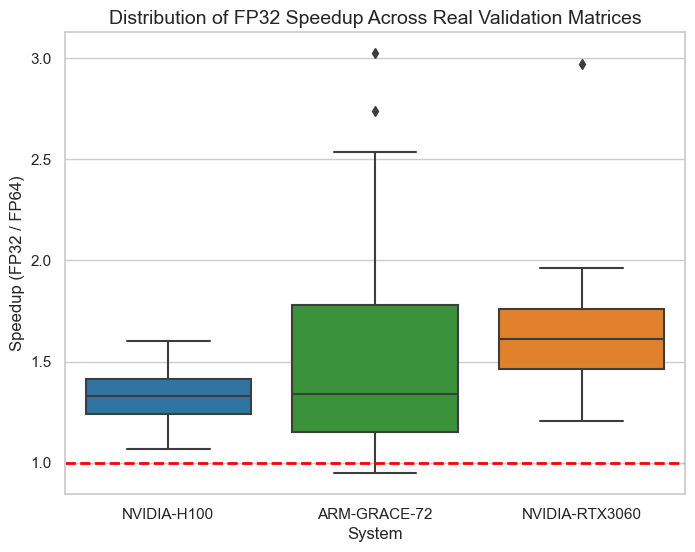

Median Speedups:
System
ARM-GRACE-72      1.341037
NVIDIA-H100       1.330156
NVIDIA-RTX3060    1.609548
Name: speedup, dtype: float64


In [4]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_merged, x='System', y='speedup', order=systems, palette=colors, linewidth=1.5)
plt.axhline(y=1.0, color='red', linestyle='--', linewidth=2)
plt.title('Distribution of FP32 Speedup Across Real Validation Matrices', fontsize=14)
plt.ylabel('Speedup (FP32 / FP64)', fontsize=12)
plt.savefig(f'{ROOT_DIR}/validation_speedup_boxplot.pdf', bbox_inches='tight')
plt.show()

# Print Median Speedups to compare with synthetic data
medians = df_merged.groupby('System')['speedup'].median()
print("Median Speedups:")
print(medians)

---
# Speedup per Matrix (Sorted by Memory Footprint)

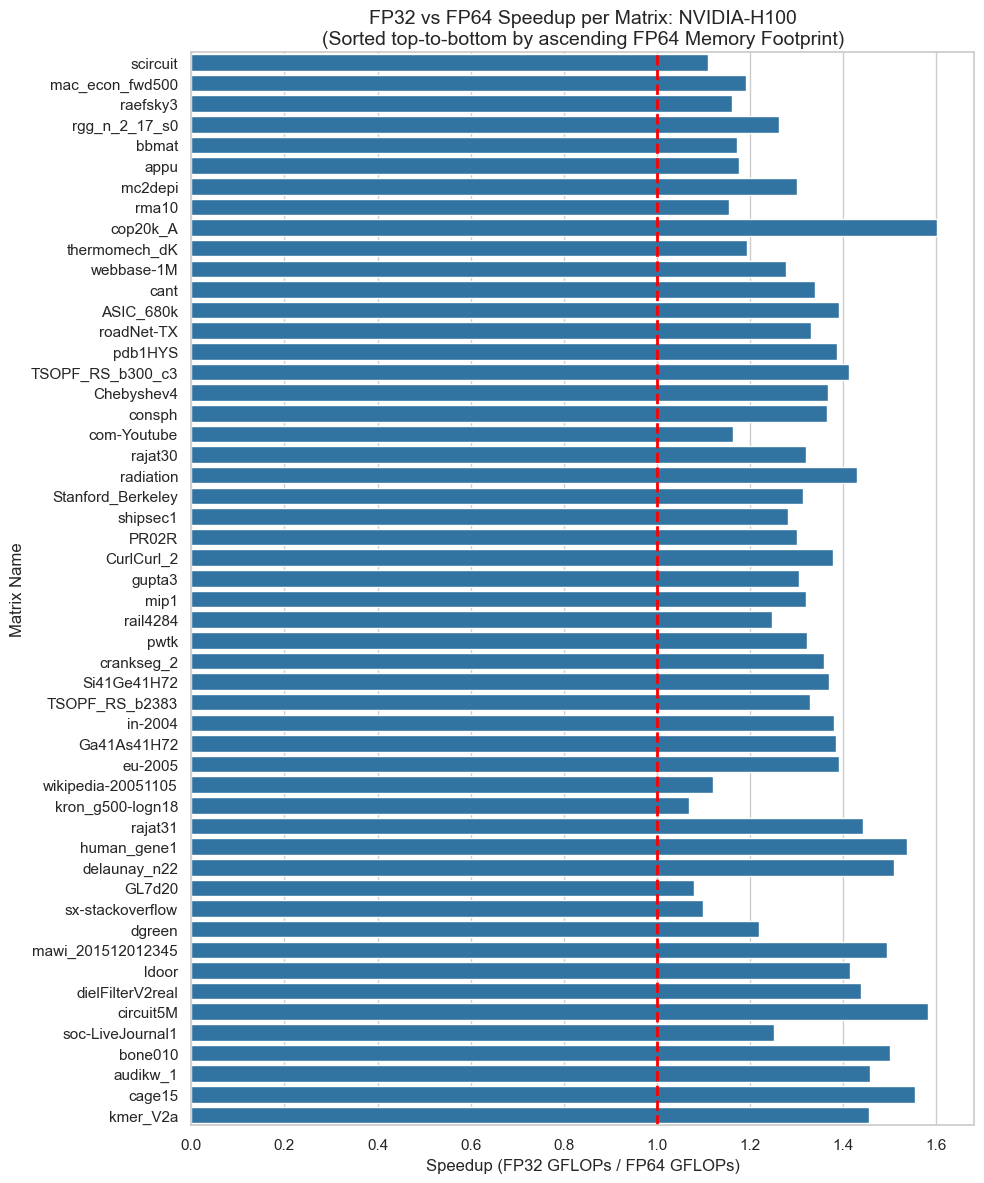

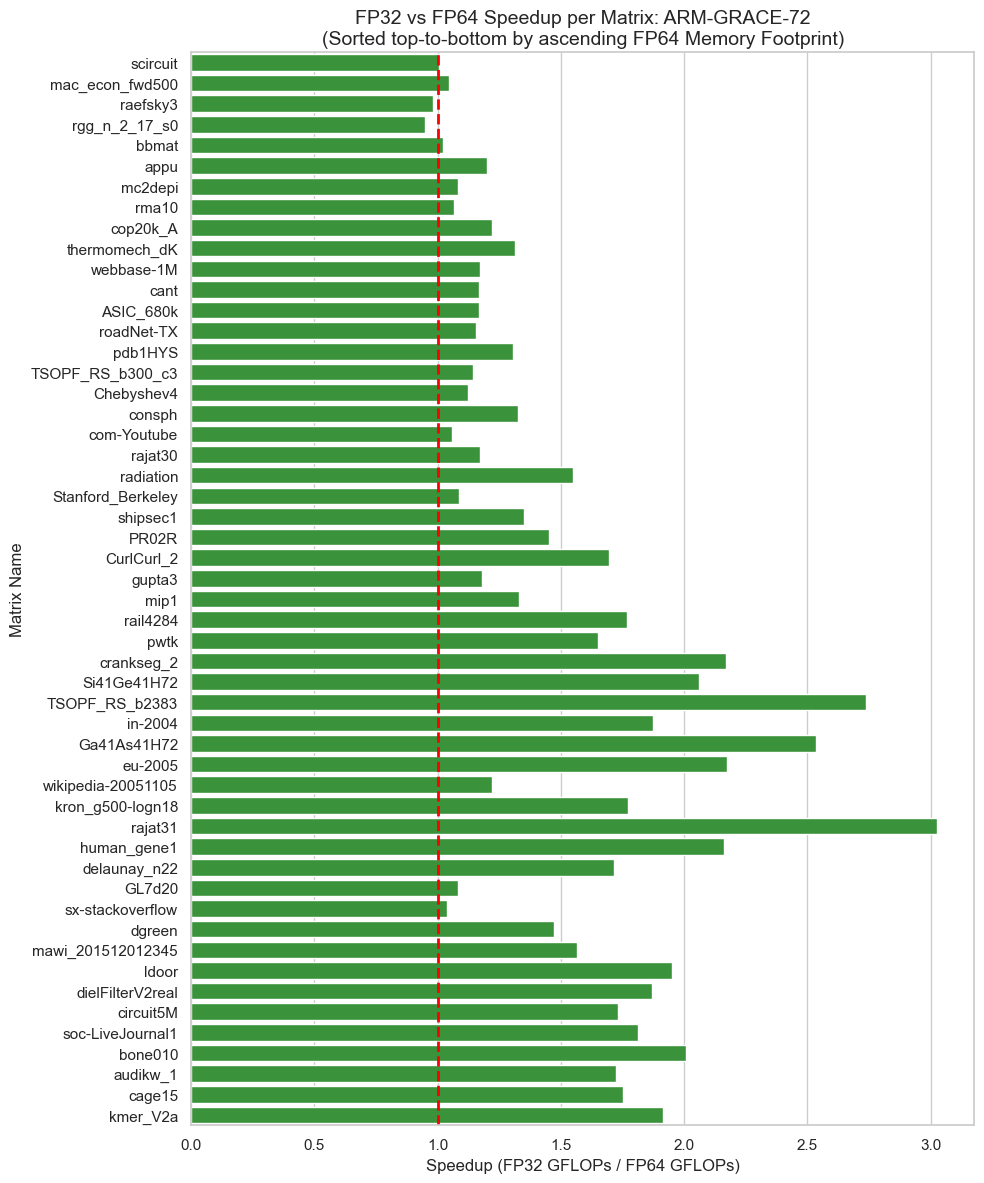

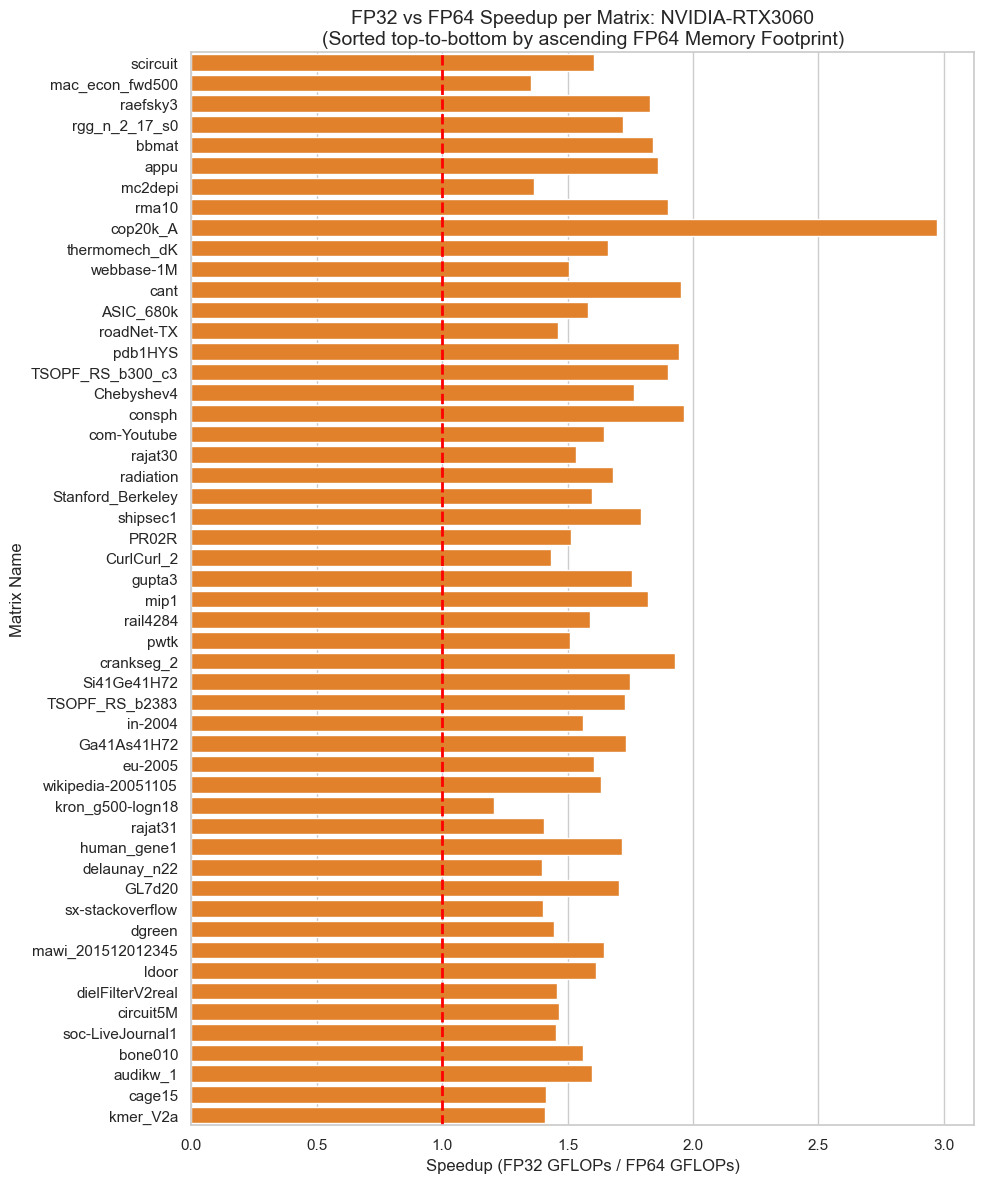

In [5]:
for sys in systems:
    df_sys = df_merged[df_merged['System'] == sys]
    
    if df_sys.empty:
        continue
        
    plt.figure(figsize=(10, 12))
    
    sns.barplot(data=df_sys, x='speedup', y='matrix_name', color=colors[sys])
    
    # Baseline (Speedup = 1.0)
    plt.axvline(x=1.0, color='red', linestyle='--', linewidth=2)
    
    plt.title(f'FP32 vs FP64 Speedup per Matrix: {sys}\n(Sorted top-to-bottom by ascending FP64 Memory Footprint)', fontsize=14)
    plt.xlabel('Speedup (FP32 GFLOPs / FP64 GFLOPs)', fontsize=12)
    plt.ylabel('Matrix Name', fontsize=12)
    
    plt.tight_layout()
    plt.savefig(f'{ROOT_DIR}/validation_speedup_matrices_{sys}.pdf', bbox_inches='tight')
    plt.show()

---
# Absolute GFLOPs Comparison per Matrix

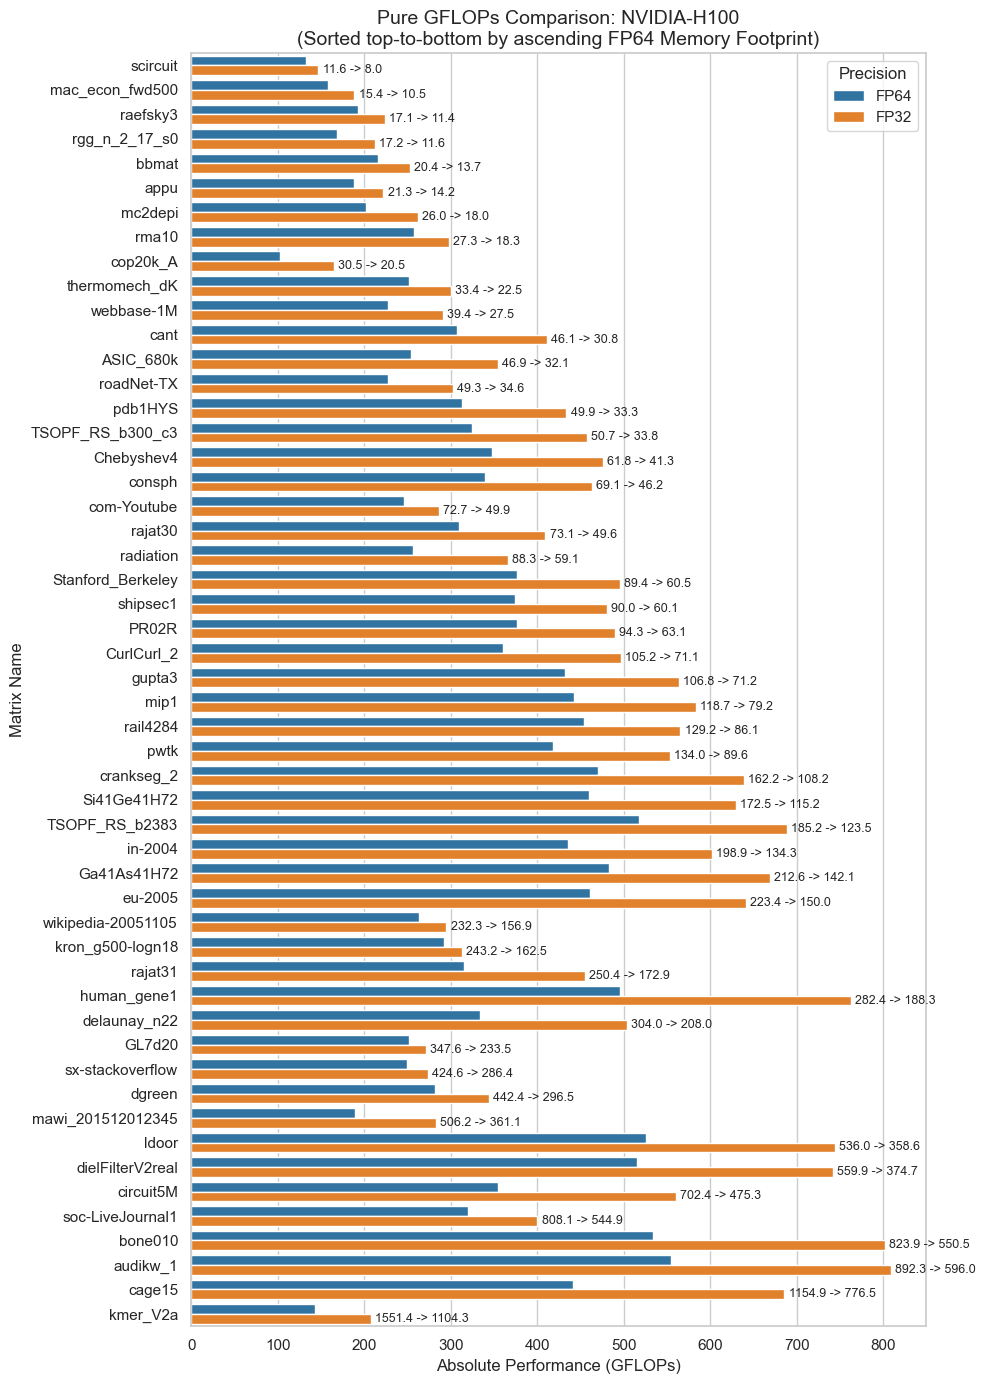

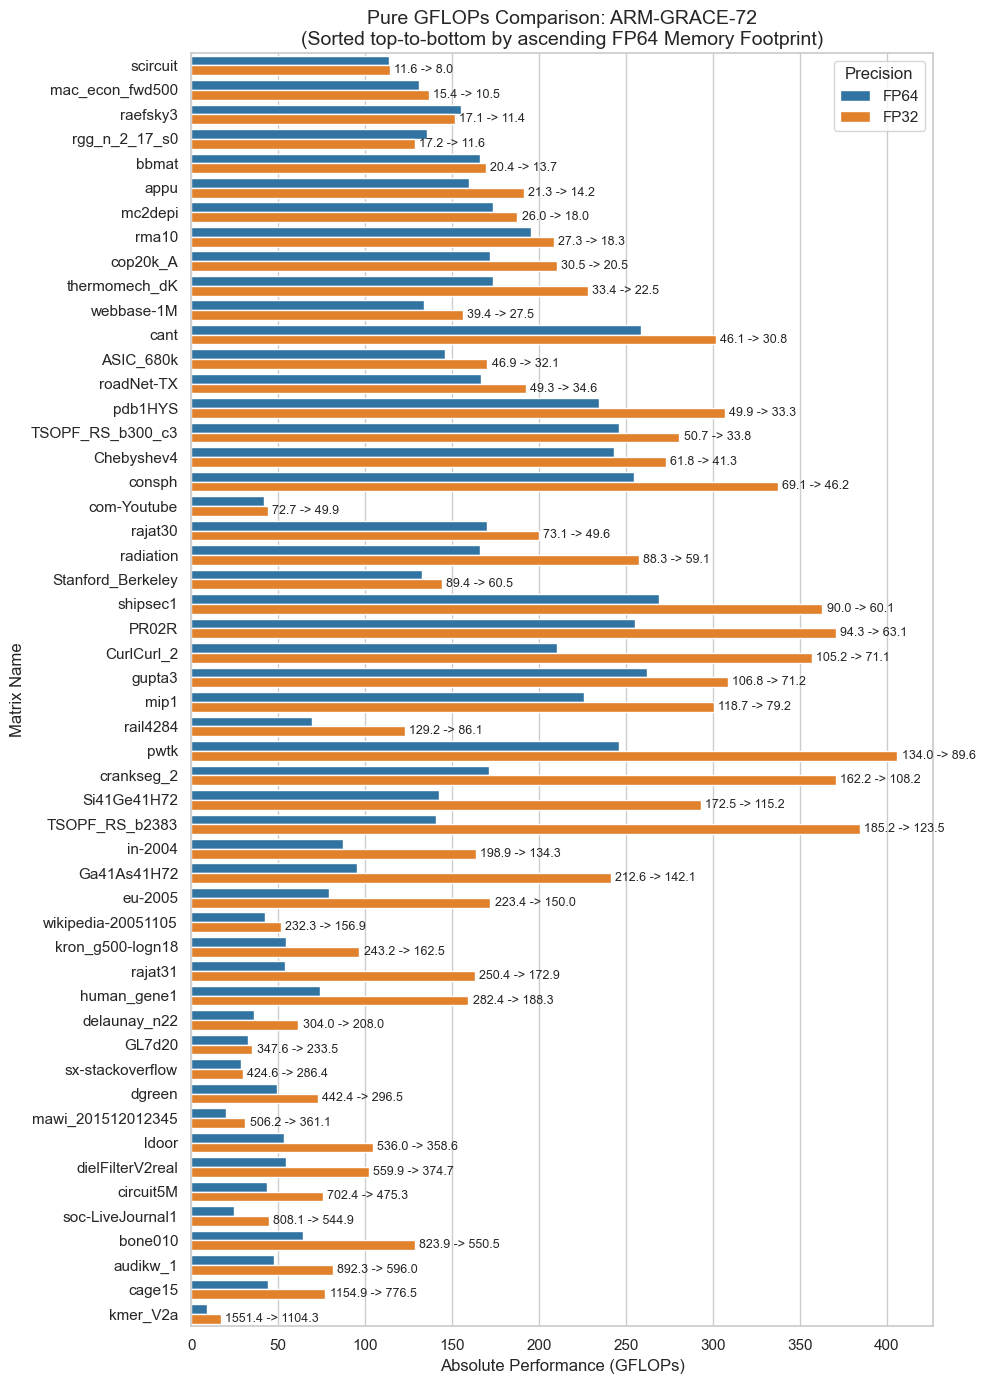

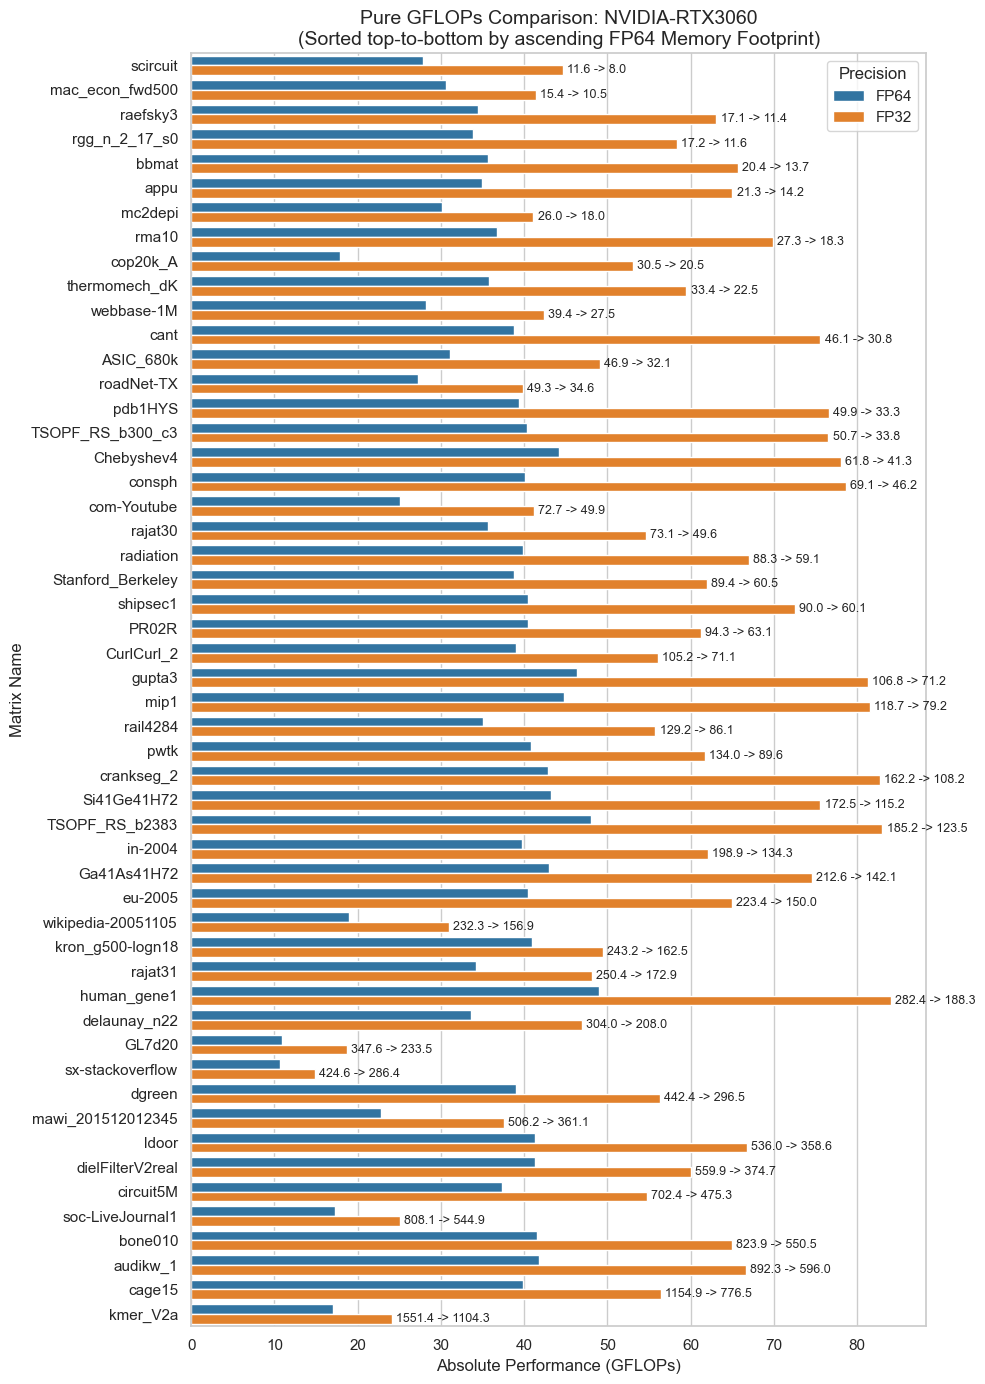

In [6]:
# Include 'mem_footprint_fp32' in id_vars to retain the data
melted_gflops = df_merged.melt(
    id_vars=['matrix_name', 'System', 'mem_footprint_fp64', 'mem_footprint_fp32'], 
    value_vars=['gflops_fp64', 'gflops_fp32'],
    var_name='Precision', 
    value_name='GFLOPs'
)

# Rename for clean legends
melted_gflops['Precision'] = melted_gflops['Precision'].map({'gflops_fp64': 'FP64', 'gflops_fp32': 'FP32'})

precision_palette = {'FP64': '#1f77b4', 'FP32': '#ff7f0e'}
# Explicitly set hue_order so FP32 is always the second container (index 1) in the plot
hue_order = ['FP64', 'FP32'] 

for sys in systems:
    df_sys = melted_gflops[melted_gflops['System'] == sys]
    
    if df_sys.empty:
        continue
        
    plt.figure(figsize=(10, 14))
    
    # Extract ordered matrices and their corresponding FP32 memory footprints natively aligned
    sys_df = df_merged[df_merged['System'] == sys]
    ordered_matrices = sys_df['matrix_name']
    
    # Assign the plot to 'ax'
    ax = sns.barplot(data=df_sys, x='GFLOPs', y='matrix_name', hue='Precision', order=ordered_matrices, 
                     hue_order=hue_order, palette=precision_palette)
    
    # Annotate the FP32 bars (ax.containers[1] corresponds to 'FP32' because of hue_order)
    fp32_mem_labels = [f"{val:.2f}" for val in sys_df['mem_footprint_fp32']] # Adjust decimal formatting as needed
    fp64_mem_labels = [f"{val:.2f}" for val in sys_df['mem_footprint_fp64']] # Adjust decimal formatting as needed
    mem_labels = [f"{val1:.1f} -> {val2:.1f}" for val1, val2 in zip(sys_df['mem_footprint_fp64'], sys_df['mem_footprint_fp32'])]

    # ax.bar_label(ax.containers[0], labels=fp64_mem_labels, padding=3, fontsize=9, color='#1f77b4')
    # ax.bar_label(ax.containers[1], labels=fp32_mem_labels, padding=3, fontsize=9, color='#ff7f0e')
    ax.bar_label(ax.containers[1], labels=mem_labels, padding=3, fontsize=9)#, color='#ff7f0e')
    
    plt.title(f'Pure GFLOPs Comparison: {sys}\n(Sorted top-to-bottom by ascending FP64 Memory Footprint)', fontsize=14)
    plt.xlabel('Absolute Performance (GFLOPs)', fontsize=12)
    plt.ylabel('Matrix Name', fontsize=12)
    
    plt.legend(title='Precision')#, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(f'{ROOT_DIR}/validation_gflops_matrices_{sys}.pdf', bbox_inches='tight')
    plt.show()

---
# Speedup vs. Memory Footprint Scatter

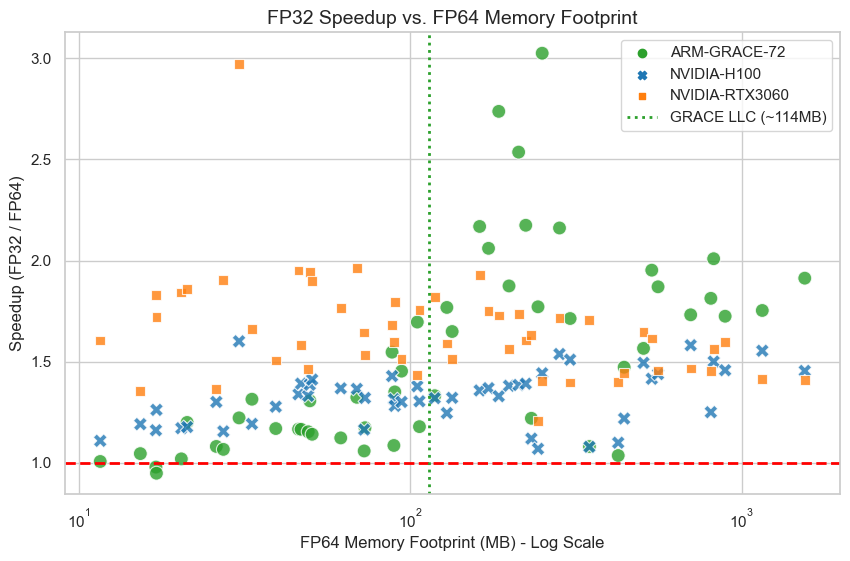

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_merged, x='mem_footprint_fp64', y='speedup', hue='System', 
                style='System', palette=colors, s=100, alpha=0.8)

plt.axhline(y=1.0, color='red', linestyle='--', linewidth=2)

# Optional: Draw Cache boundary lines (Adjust values as needed)
plt.axvline(x=114, color=colors['ARM-GRACE-72'], linestyle=':', linewidth=2, label='GRACE LLC (~114MB)')
# plt.axvline(x=50, color=colors['NVIDIA-H100'], linestyle=':', linewidth=2, label='H100 L2 (~50MB)')

plt.xscale('log')
plt.title('FP32 Speedup vs. FP64 Memory Footprint', fontsize=14)
plt.xlabel('FP64 Memory Footprint (MB) - Log Scale', fontsize=12)
plt.ylabel('Speedup (FP32 / FP64)', fontsize=12)
plt.legend()
plt.savefig('./Plots/validation/fp32_vs_fp64/validation_speedup_vs_mem.pdf', bbox_inches='tight')
plt.show()